# CLIP ViT-B/32 — Production Fine-Tuning v2

25 classes from `arch-datasets/`. VPS CPU-only target (< 6 GB RAM).

## Key changes from v1
- `open_clip` throughout — matches production `embedder.py`
- Multi-prompt training (5 prompts/class, random sample per step)
- Hard-negative-aware batch sampler (confusion cluster packing)
- Oversampling small classes → balanced training without extra images
- Stronger augmentation → effective 3–4x dataset size
- Data quality filter (drop mislabelled via zero-shot self-scoring)
- Temperature calibration (L-BFGS NLL fit, ECE measurement)
- ONNX + INT8 export + CPU latency benchmark
- Full retrieval-grade evaluation (R@1/3/5, MRR, hard-neg pass rate)

## Targets
| Metric | Target |
|--------|--------|
| Classification accuracy (balanced) | ≥ 90% |
| Macro F1 | ≥ 90% |
| Hard-negative pass rate | ≥ 80% |
| Semantic R@1 (prompt bank) | ≥ 70% |
| ECE | < 0.10 |
| Noise confidence p95 | < 50% |
| CPU latency p95 (ONNX INT8) | < 200ms |

## 0. Config

In [1]:
import math, os, random, time, warnings
from collections import defaultdict
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import open_clip
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Dataset, Sampler
from torchvision import transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_ROOT      = Path("./arch-datasets")
CHECKPOINT_DIR = Path("./checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR  = CHECKPOINT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
BEST_PT        = CHECKPOINT_DIR / "best_clip_v2.pt"
ONNX_FP32      = CHECKPOINT_DIR / "clip_visual_fp32.onnx"
ONNX_INT8      = CHECKPOINT_DIR / "clip_visual_int8.onnx"

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME = "ViT-B-32"   # matches production embedder.py
PRETRAINED = "openai"

# ── Hardware ──────────────────────────────────────────────────────────────────
SEED    = 42
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 16     # larger = better contrastive signal; 16 fits 6 GB
NUM_WORKERS  = 0

S1_EPOCHS    = 5      # freeze visual, train text + projections
S1_LR        = 5e-6
S2_EPOCHS    = 10     # unfreeze visual resblocks 10 & 11
S2_LR        = 5e-7

WEIGHT_DECAY    = 0.1
GRAD_CLIP       = 1.0
WARMUP_RATIO    = 0.1
EARLY_STOP_PAT  = 5
LABEL_SMOOTHING = 0.1

# ── Data ──────────────────────────────────────────────────────────────────────
# Oversample each class up to this count so the dataset is balanced.
# With 122 (min) → 280, augmentation makes every extra sample genuinely different.
OVERSAMPLE_TO       = 280
VAL_PER_CLASS       = 20    # held out before oversampling
QUALITY_THRESHOLD   = 0.05  # drop images where zero-shot confidence < this

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device        : {DEVICE}")
print(f"open_clip ver : {open_clip.__version__}")

c:\Users\shiva\miniforge3\envs\torch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device        : cuda
open_clip ver : 3.3.0


## 1. Label Taxonomy — 25 Classes, 5 Prompts Each

5 prompts per class: style name, visual features, material/context, famous
example, loose descriptor. Randomly sampled each training step so the text
encoder builds a semantic cluster, not a single point.

Prompts deliberately cover the mixed-image case — some prompts are broad
so a building showing partial style cues still pulls toward the right cluster.

In [2]:
# fmt: off
LABEL_PROMPTS: dict[str, list[str]] = {

    "Achaemenid architecture": [
        "a photo of Achaemenid architecture",
        "ancient Persian palace with tall stone columns and carved reliefs",
        "Persepolis style massive stone terrace with lamassu gate guardians",
        "ancient Iranian ceremonial building with hypostyle hall",
        "Achaemenid imperial stone platform with monumental staircase",
    ],
    "American Foursquare architecture": [
        "a photo of American Foursquare architecture",
        "American Foursquare house with pyramidal hipped roof and front porch",
        "boxy two-storey Prairie Box house with wide dormer windows",
        "early 20th century square American brick house with large veranda",
        "Foursquare residential building with symmetrical facade",
    ],
    "American craftsman style": [
        "a photo of American craftsman style architecture",
        "Craftsman bungalow with wide front porch and exposed rafter tails",
        "Arts-and-Crafts bungalow with tapered columns on brick porch piers",
        "low-pitched Craftsman house with overhanging eaves and wood trim",
        "California bungalow with natural wood and handcrafted stone details",
    ],
    "Ancient Egyptian architecture": [
        "a photo of Ancient Egyptian architecture",
        "ancient Egyptian stone temple with pylons and obelisks",
        "pharaonic columns and hieroglyphic relief carvings in stone",
        "massive stone hypostyle hall with lotus-capital columns",
        "Egyptian pyramid or mortuary temple with axial planning",
    ],
    "Art Deco architecture": [
        "a photo of Art Deco architecture",
        "Art Deco skyscraper with stepped crown and geometric ornament",
        "1930s Art Deco building with zigzag frieze and polished metal details",
        "streamlined Art Deco facade with sunburst motif and terrazzo",
        "Art Deco cinema or hotel with fluted pilasters and vertical tower",
    ],
    "Art Nouveau architecture": [
        "a photo of Art Nouveau architecture",
        "Art Nouveau building with organic curved ironwork and floral motifs",
        "Jugendstil or Secessionist facade with sinuous plant-form ornament",
        "Art Nouveau building with mosaic tiles and sculpted female figures",
        "undulating facade with whiplash curves and nature-inspired ornament",
    ],
    "Baroque architecture": [
        "a photo of Baroque architecture",
        "dramatic Baroque church facade with twisted columns and curved gable",
        "ornate European Baroque palace with dynamic sculptural decoration",
        "bold convex and concave Baroque church facade with rich ornament",
        "grand Baroque building with movement, curves, and gilded interior",
    ],
    "Bauhaus architecture": [
        "a photo of Bauhaus architecture",
        "Bauhaus building with glass curtain wall and flat roof",
        "functionalist Bauhaus school with industrial glazing and no ornament",
        "Gropius-style cubic building with ribbon windows",
        "modernist workshop block with steel frame and glass facade",
    ],
    "Beaux-Arts architecture": [
        "a photo of Beaux-Arts architecture",
        "grand Beaux-Arts building with rusticated base and sculptural keystones",
        "monumental American Beaux-Arts civic building with paired columns",
        "ornate stone facade with mansard roof and classical cartouches",
        "Ecole des Beaux-Arts inspired public building with arched windows",
    ],
    "Byzantine architecture": [
        "a photo of Byzantine architecture",
        "church with large central dome and rich gold mosaic interior",
        "Eastern Roman basilica with pendentive dome and rounded apse",
        "Byzantine church with striped stonework and rounded arches",
        "domed Orthodox church with drum tower and radiating chapels",
    ],
    "Chicago school architecture": [
        "a photo of Chicago school architecture",
        "early Chicago school steel-frame office tower with Chicago window",
        "Sullivan or Burnham style tall commercial building with terracotta",
        "early skyscraper with tripartite facade base shaft and capital",
        "Chicago school block with large plate-glass display windows",
    ],
    "Colonial architecture": [
        "a photo of Colonial architecture",
        "American Colonial house with clapboard siding and shuttered windows",
        "symmetrical Colonial Revival facade with central entrance and dormers",
        "New England Colonial building with steep gable roof and chimney",
        "white Colonial church with steeple and round-headed windows",
    ],
    "Deconstructivism": [
        "a photo of Deconstructivist architecture",
        "fragmented angular building with colliding volumes and tilted planes",
        "Zaha Hadid or Frank Gehry style non-rectilinear sculptural building",
        "contemporary building with shattered geometric forms and skewed facades",
        "deconstructivist structure with flowing metallic skin and sharp angles",
    ],
    "Edwardian architecture": [
        "a photo of Edwardian architecture",
        "Edwardian house with bay window red brick and white plaster details",
        "early 20th century British Edwardian terrace with sash windows",
        "Edwardian baroque civic building with domed corner tower",
        "Edwardian garden suburb house with roughcast render and tile roof",
    ],
    "Georgian architecture": [
        "a photo of Georgian architecture",
        "symmetrical Georgian brick townhouse with sash windows and fanlight",
        "18th century English Georgian terrace with classical doorway",
        "restrained Georgian facade with string courses and Palladian window",
        "Georgian colonial brick building with hipped roof and white trim",
    ],
    "Gothic architecture": [
        "a photo of Gothic architecture",
        "Gothic cathedral with pointed arches and flying buttresses",
        "soaring medieval stone cathedral with ribbed vaults and rose window",
        "Gothic church facade with three portals and lancet windows",
        "skeletal stone cathedral with stained glass and pointed spires",
    ],
    "Greek Revival architecture": [
        "a photo of Greek Revival architecture",
        "Greek Revival building with temple portico and fluted Doric columns",
        "19th century Greek Revival courthouse or bank with pediment",
        "white-columned civic building inspired by ancient Greek temples",
        "antebellum Greek Revival mansion with full-height colonnade",
    ],
    "International style": [
        "a photo of International style architecture",
        "modernist glass and steel curtain-wall building with no ornament",
        "Le Corbusier or Mies van der Rohe style office tower",
        "flat-roofed white-rendered International Style villa on pilotis",
        "repetitive ribbon-window facade of a modernist tower block",
    ],
    "Novelty architecture": [
        "a photo of Novelty architecture",
        "novelty or programmatic building shaped like a giant object",
        "roadside architecture built to look like a shoe hat or food item",
        "duck building or mimic architecture with sculptural figurative form",
        "eccentric commercial building with theme-park or pop-art aesthetic",
    ],
    "Palladian architecture": [
        "a photo of Palladian architecture",
        "Palladian villa with strict symmetry and pedimented central portico",
        "elegant neoclassical country house with Venetian window and wings",
        "architecture inspired by Andrea Palladio with classical temple front",
        "Palladian bridge or rotunda with Ionic columns and balustrade",
    ],
    "Postmodern architecture": [
        "a photo of Postmodern architecture",
        "Postmodern building with ironic classical columns and pastel colors",
        "Michael Graves or Philip Johnson style Postmodern skyscraper",
        "Postmodern building with oversized historical ornament and bright cladding",
        "commercial facade mixing historical motifs with modern materials",
    ],
    "Queen Anne architecture": [
        "a photo of Queen Anne architecture",
        "Victorian Queen Anne house with wrap-around porch and decorative spindles",
        "asymmetrical Queen Anne facade with turret and patterned shingles",
        "ornate Victorian villa with steep gables and stained glass windows",
        "Queen Anne style building with terracotta tile and sunflower motifs",
    ],
    "Romanesque architecture": [
        "a photo of Romanesque architecture",
        "massive stone Romanesque church with rounded arches and thick walls",
        "Romanesque abbey with squat tower and carved stone tympanum",
        "fortress-like Romanesque cathedral with blind arcading",
        "barrel-vaulted Romanesque nave with compound piers",
    ],
    "Russian Revival architecture": [
        "a photo of Russian Revival architecture",
        "Russian Revival building with onion domes and colourful tilework",
        "19th century Russian historicist architecture with tent-roof towers",
        "elaborately patterned Russian Orthodox church with kokoshnik arches",
        "Russian Revival civic building with corbelled arches and bright faience",
    ],
    "Tudor Revival architecture": [
        "a photo of Tudor Revival architecture",
        "Tudor Revival house with half-timbered facade and steep cross-gables",
        "Elizabethan Revival building with black-and-white timber framing",
        "mock-Tudor house with decorative bargeboards and leaded windows",
        "interwar Tudor Revival cottage with clay-tile roof and tall chimneys",
    ],
}
# fmt: on

ALL_CLASSES  = sorted(LABEL_PROMPTS.keys())
CLASS_TO_IDX = {c: i for i, c in enumerate(ALL_CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
N_CLASSES    = len(ALL_CLASSES)

print(f"Classes: {N_CLASSES}")

Classes: 25


## 2. Confusion Clusters

Groups of visually similar styles. Batch sampler packs them together so
the model must discriminate within the cluster, not just style vs. noise.

In [3]:
CONFUSION_CLUSTERS: list[list[str]] = [
    # Gothic / Romanesque  — hardest confusion pair in v1
    ["Gothic architecture", "Romanesque architecture"],

    # Baroque / Beaux-Arts / Palladian — grand ornate European
    ["Baroque architecture", "Beaux-Arts architecture", "Palladian architecture"],

    # Neoclassical family
    ["Greek Revival architecture", "Colonial architecture", "Georgian architecture"],

    # Victorian family
    ["Queen Anne architecture", "Tudor Revival architecture", "Edwardian architecture"],

    # Early Modern
    ["Bauhaus architecture", "International style", "Chicago school architecture"],

    # American residential
    ["American craftsman style", "American Foursquare architecture"],

    # Contemporary / avant-garde
    ["Postmodern architecture", "Deconstructivism"],

    # Art styles
    ["Art Deco architecture", "Art Nouveau architecture"],

    # Ancient / religious
    ["Ancient Egyptian architecture", "Achaemenid architecture", "Byzantine architecture"],

    # Standalone (still need cluster membership for sampler)
    ["Russian Revival architecture", "Novelty architecture"],
]

CLASS_TO_CLUSTER: dict[str, int] = {}
for ci, cluster in enumerate(CONFUSION_CLUSTERS):
    for cls in cluster:
        if cls in CLASS_TO_IDX:
            CLASS_TO_CLUSTER[cls] = ci

unassigned = [c for c in ALL_CLASSES if c not in CLASS_TO_CLUSTER]
print(f"Assigned: {len(CLASS_TO_CLUSTER)}/{N_CLASSES}  Unassigned: {unassigned}")

Assigned: 25/25  Unassigned: []


## 3. Data Loading, Quality Filter & Balanced Split

In [4]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def discover(root: Path) -> dict[str, list[Path]]:
    out: dict[str, list[Path]] = {}
    for d in sorted(root.iterdir()):
        if not d.is_dir() or d.name not in CLASS_TO_IDX:
            continue
        paths = [f for f in d.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXT]
        out[d.name] = paths
    return out

raw_data = discover(DATA_ROOT)
print("Per-class image count:")
for cls in sorted(raw_data, key=lambda c: len(raw_data[c])):
    print(f"  {len(raw_data[cls]):4d}  {cls}")

Per-class image count:
   122  Deconstructivism
   125  Chicago school architecture
   150  Ancient Egyptian architecture
   159  Postmodern architecture
   165  Art Nouveau architecture
   169  American craftsman style
   170  Novelty architecture
   187  Russian Revival architecture
   194  Romanesque architecture
   196  Greek Revival architecture
   200  Art Deco architecture
   201  Edwardian architecture
   202  Byzantine architecture
   210  International style
   217  Baroque architecture
   222  Gothic architecture
   223  Bauhaus architecture
   227  Georgian architecture
   230  Palladian architecture
   233  Beaux-Arts architecture
   293  Tudor Revival architecture
   295  Queen Anne architecture
   303  American Foursquare architecture
   303  Colonial architecture
   323  Achaemenid architecture


In [5]:
# Zero-shot quality filter — base weights, no checkpoint
# Drops images where base CLIP confidence for their own label < QUALITY_THRESHOLD.
# Removes mislabelled / corrupt files before they pollute training.

_qm, _, _qp = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED)
_qm.eval()
_qt = open_clip.get_tokenizer(MODEL_NAME)

_cls_list = sorted(raw_data.keys())
_canonical = [LABEL_PROMPTS[c][0] for c in _cls_list]
with torch.no_grad():
    _tok = _qt(_canonical)
    _tf  = _qm.encode_text(_tok)
    _tf  = _tf / _tf.norm(dim=-1, keepdim=True)

_ci = {c: i for i, c in enumerate(_cls_list)}

def _qs(path: Path, cls: str) -> float:
    try:
        x = _qp(Image.open(path).convert("RGB")).unsqueeze(0)
        with torch.no_grad():
            f = _qm.encode_image(x)
            f = f / f.norm(dim=-1, keepdim=True)
            return float((100.0 * f @ _tf.T).softmax(dim=-1)[0, _ci[cls]])
    except Exception:
        return 0.0

filtered_data: dict[str, list[Path]] = {}
total_dropped = 0
for cls, paths in raw_data.items():
    kept = [p for p in tqdm(paths, desc=cls, leave=False) if _qs(p, cls) >= QUALITY_THRESHOLD]
    dropped = len(paths) - len(kept)
    total_dropped += dropped
    filtered_data[cls] = kept
    print(f"  {cls}: {len(paths)} → {len(kept)} (dropped {dropped})")

print(f"\nTotal dropped: {total_dropped}")
del _qm, _tf
torch.cuda.empty_cache() if DEVICE == "cuda" else None

  Achaemenid architecture: 323 → 318 (dropped 5)


  American craftsman style: 169 → 167 (dropped 2)


  American Foursquare architecture: 303 → 296 (dropped 7)


  Ancient Egyptian architecture: 150 → 148 (dropped 2)


  Art Deco architecture: 200 → 185 (dropped 15)


...

  Postmodern architecture: 159 → 124 (dropped 35)


  Queen Anne architecture: 295 → 226 (dropped 69)


  Romanesque architecture: 194 → 190 (dropped 4)


  Russian Revival architecture: 187 → 176 (dropped 11)


  Tudor Revival architecture: 293 → 283 (dropped 10)

Total dropped: 774


In [6]:
def split_and_oversample(
    data: dict[str, list[Path]],
    val_per_class: int,
    oversample_to: int,
    seed: int = SEED,
) -> tuple[list[Path], list[str], list[Path], list[str]]:
    """
    1. Stratified val split (val_per_class per class).
    2. Oversample training paths with replacement to oversample_to per class.
       Oversampled copies get different augmentation each epoch → genuine variety.
    """
    rng = np.random.default_rng(seed)
    tr_paths, tr_labels = [], []
    va_paths, va_labels = [], []

    for cls, paths in data.items():
        shuffled = list(paths)
        rng.shuffle(shuffled)
        n_val  = min(val_per_class, max(1, len(shuffled) // 5))
        va_paths.extend(shuffled[:n_val])
        va_labels.extend([cls] * n_val)

        remaining = shuffled[n_val:]
        if len(remaining) == 0:
            remaining = shuffled  # edge case: tiny class

        # Oversample with replacement to oversample_to
        n_needed = max(oversample_to, len(remaining))
        oversampled = list(rng.choice(remaining, size=n_needed, replace=(n_needed > len(remaining))))
        tr_paths.extend(oversampled)
        tr_labels.extend([cls] * n_needed)

    return tr_paths, tr_labels, va_paths, va_labels

train_paths, train_labels, val_paths, val_labels = split_and_oversample(
    filtered_data, VAL_PER_CLASS, OVERSAMPLE_TO
)

print(f"Train : {len(train_paths)} samples ({len(set(train_labels))} classes)")
print(f"Val   : {len(val_paths)} samples")
print(f"Effective images per class: {OVERSAMPLE_TO}")

Train : 7018 samples (25 classes)
Val   : 485 samples
Effective images per class: 280


## 4. Dataset & Hard-Negative-Aware Batch Sampler

In [7]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275,  0.40821073),
        std= (0.26862954, 0.26130258, 0.27577711),
    ),
])


class ArchDataset(Dataset):
    """Returns (image_tensor, text_tokens, class_idx).
    Prompt randomly sampled from LABEL_PROMPTS[class] per call.
    """
    def __init__(self, paths, labels, tokenizer, transform, augment=True):
        self.paths     = paths
        self.labels    = labels
        self.tokenizer = tokenizer
        self.transform = transform
        self.augment   = augment

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        cls = self.labels[idx]
        img = Image.open(self.paths[idx]).convert("RGB")
        img_t = self.transform(img)
        prompt = random.choice(LABEL_PROMPTS[cls])
        txt_t  = self.tokenizer([prompt])[0]
        return img_t, txt_t, CLASS_TO_IDX[cls]


class HardNegativeBatchSampler(Sampler):
    """Each batch: ~50% from one confusion cluster, rest random.
    Forces model to discriminate within visually similar style groups.
    """
    def __init__(self, labels: list[str], batch_size: int):
        self.batch_size = batch_size
        self.n_batches  = len(labels) // batch_size
        self.all        = list(range(len(labels)))

        self.cluster_idx: dict[int, list[int]] = defaultdict(list)
        for i, lbl in enumerate(labels):
            ci = CLASS_TO_CLUSTER.get(lbl, -1)
            self.cluster_idx[ci].append(i)

        self.cluster_ids = [ci for ci in self.cluster_idx if ci >= 0]

    def __len__(self): return self.n_batches

    def __iter__(self):
        pool = self.all.copy()
        random.shuffle(pool)
        pool_iter = iter(pool)
        half = self.batch_size // 2

        for _ in range(self.n_batches):
            ci   = random.choice(self.cluster_ids)
            hard = random.choices(self.cluster_idx[ci], k=half)
            rest = []
            while len(rest) < self.batch_size - half:
                try:
                    rest.append(next(pool_iter))
                except StopIteration:
                    rest.append(random.choice(self.all))
            batch = hard + rest
            random.shuffle(batch)
            yield batch

## 5. Load Model (open_clip — matches production embedder)

In [8]:
model, _, val_preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME, pretrained=PRETRAINED
)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
model     = model.to(DEVICE)

# Convert to FP32 — avoids GradScaler FP16 unscale error on CUDA
if DEVICE == "cuda":
    for p in model.parameters():
        p.data = p.data.float()

with torch.no_grad():
    model.logit_scale.fill_(math.log(1 / 0.07))

# DataLoaders
AVAIL_CLASSES = sorted(filtered_data.keys())

train_ds = ArchDataset(train_paths, train_labels, tokenizer, TRAIN_TRANSFORM, augment=True)
val_ds   = ArchDataset(val_paths,   val_labels,   tokenizer, val_preprocess,  augment=False)

train_sampler = HardNegativeBatchSampler(train_labels, BATCH_SIZE)
train_loader  = DataLoader(train_ds, batch_sampler=train_sampler,
                           num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))
val_loader    = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

# Zero-shot baseline
@torch.no_grad()
def evaluate(loader=val_loader, classes=AVAIL_CLASSES):
    model.eval()
    prompts = [LABEL_PROMPTS[c][0] for c in classes]
    tok = tokenizer(prompts).to(DEVICE)
    txt = model.encode_text(tok)
    txt = txt / txt.norm(dim=-1, keepdim=True)

    c2l = {c: i for i, c in enumerate(classes)}
    preds, tgts = [], []
    for imgs, _, labels in loader:
        imgs = imgs.to(DEVICE)
        f    = model.encode_image(imgs)
        f    = f / f.norm(dim=-1, keepdim=True)
        pred = (100.0 * f @ txt.T).argmax(dim=1).cpu().numpy()
        preds.extend(pred)
        for g in labels.numpy():
            cn = IDX_TO_CLASS[g]
            tgts.append(c2l.get(cn, -1))

    from sklearn.metrics import accuracy_score
    pairs = [(p, t) for p, t in zip(preds, tgts) if t >= 0]
    return accuracy_score([t for _, t in pairs], [p for p, _ in pairs])

print(f"\nBaseline zero-shot val accuracy: {evaluate():.4f}")

Train batches: 438  Val batches: 31

Baseline zero-shot val accuracy: 0.6144


## 6. Two-Stage Training

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def closs(li, lt):
    lbl = torch.arange(li.shape[0], device=li.device)
    return (criterion(li, lbl) + criterion(lt, lbl)) / 2

def make_opt(lr):
    return optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, betas=(0.9, 0.98), eps=1e-6, weight_decay=WEIGHT_DECAY,
    )

def make_sched(opt, total, warmup):
    def fn(s):
        if s < warmup:
            return s / max(1, warmup)
        p = (s - warmup) / max(1, total - warmup)
        return 0.5 * (1 + math.cos(math.pi * p))
    return optim.lr_scheduler.LambdaLR(opt, fn)

# Stage 1 freeze
for p in model.visual.parameters():
    p.requires_grad = False
for name, p in model.visual.named_parameters():
    if "resblocks.11" in name:
        p.requires_grad = True
for p in model.transformer.parameters():
    p.requires_grad = True
if hasattr(model, "text_projection") and model.text_projection is not None:
    model.text_projection.requires_grad = True
model.logit_scale.requires_grad = True

TOTAL_EPOCHS = S1_EPOCHS + S2_EPOCHS
total_steps  = len(train_loader) * TOTAL_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

opt    = make_opt(S1_LR)
sched  = make_sched(opt, total_steps, warmup_steps)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

best_acc   = 0.0
no_improve = 0
step       = 0

for epoch in range(1, TOTAL_EPOCHS + 1):

    if epoch == S1_EPOCHS + 1:
        print("\n→ Stage 2: unlock visual resblocks 10 & 11")
        for name, p in model.visual.named_parameters():
            if "resblocks.10" in name or "resblocks.11" in name:
                p.requires_grad = True
        opt   = make_opt(S2_LR)
        sched = make_sched(opt, total_steps - step, warmup_steps // 2)

    model.train()
    ep_loss = 0.0
    bar = tqdm(train_loader, desc=f"E{epoch}/{TOTAL_EPOCHS}")

    for imgs, txts, _ in bar:
        imgs = imgs.to(DEVICE, non_blocking=True)
        txts = txts.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)

        ctx = torch.cuda.amp.autocast() if USE_AMP else nullcontext()
        with ctx:
            fi = model.encode_image(imgs)
            ft = model.encode_text(txts)
            fi = fi / fi.norm(dim=-1, keepdim=True)
            ft = ft / ft.norm(dim=-1, keepdim=True)
            scale = model.logit_scale.exp()
            li = scale * fi @ ft.T
            loss = closs(li, li.T)

        if not torch.isfinite(loss):
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        with torch.no_grad():
            model.logit_scale.clamp_(0, math.log(100))
        scaler.step(opt)
        scaler.update()
        sched.step()
        step += 1
        ep_loss += loss.item()
        bar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{sched.get_last_lr()[0]:.1e}")

    val_acc = evaluate()
    print(f"  E{epoch}  loss={ep_loss/len(train_loader):.4f}  val_acc={val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        no_improve = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_accuracy": best_acc,
            "available_classes": AVAIL_CLASSES,
        }, BEST_PT)
        print(f"  ✓ best saved  acc={best_acc:.4f}")
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PAT:
            print("  early stop")
            break

print(f"\nBest val accuracy: {best_acc:.4f}")

E1/15: 100%|██████████| 438/438 [04:11<00:00,  1.74it/s, loss=1.5498, lr=3.3e-06]


  E1  loss=1.9148  val_acc=0.8021
  ✓ best saved  acc=0.8021


E2/15: 100%|██████████| 438/438 [04:06<00:00,  1.78it/s, loss=1.4287, lr=5.0e-06]


  E2  loss=1.6331  val_acc=0.8062
  ✓ best saved  acc=0.8062


E3/15: 100%|██████████| 438/438 [03:59<00:00,  1.83it/s, loss=1.7179, lr=4.8e-06]


...

  E13  loss=1.4486  val_acc=0.8742


E14/15: 100%|██████████| 438/438 [04:01<00:00,  1.81it/s, loss=1.9537, lr=1.4e-08]


  E14  loss=1.4403  val_acc=0.8701


E15/15: 100%|██████████| 438/438 [04:01<00:00,  1.81it/s, loss=1.4190, lr=0.0e+00]


  E15  loss=1.4546  val_acc=0.8701

Best val accuracy: 0.8742


## 7. Temperature Calibration

Fits scalar T on val set via L-BFGS NLL minimization.
Calibrated logits = raw_logits / T.
Target ECE < 0.10.

In [10]:
ckpt = torch.load(BEST_PT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"], strict=False)
model.eval()
CAL_CLASSES = ckpt.get("available_classes", AVAIL_CLASSES)
print(f"Loaded epoch {ckpt['epoch']}  best_acc={ckpt['best_accuracy']:.4f}")


@torch.no_grad()
def collect_logits(loader, classes=CAL_CLASSES):
    prompts = [LABEL_PROMPTS[c][0] for c in classes]
    tok = tokenizer(prompts).to(DEVICE)
    txt = model.encode_text(tok)
    txt = txt / txt.norm(dim=-1, keepdim=True)
    c2l = {c: i for i, c in enumerate(classes)}

    all_logits, all_tgts = [], []
    for imgs, _, labels in loader:
        imgs = imgs.to(DEVICE)
        f    = model.encode_image(imgs)
        f    = f / f.norm(dim=-1, keepdim=True)
        all_logits.append((f @ txt.T).cpu())
        for g in labels.numpy():
            all_tgts.append(c2l.get(IDX_TO_CLASS[g], 0))

    return torch.cat(all_logits), torch.tensor(all_tgts)


def ece(logits, labels, n_bins=15):
    probs = logits.softmax(dim=-1)
    conf, pred = probs.max(dim=1)
    correct = pred.eq(labels).float()
    err = 0.0
    for i in range(n_bins):
        lo, hi = i / n_bins, (i + 1) / n_bins
        m = (conf > lo) & (conf <= hi)
        if m.sum() == 0:
            continue
        err += m.float().mean().item() * abs(correct[m].mean().item() - conf[m].mean().item())
    return err


val_logits, val_tgts = collect_logits(val_loader)

print(f"ECE before calibration: {ece(val_logits * 100.0, val_tgts):.4f}")

T = nn.Parameter(torch.ones(1) * 1.5)
cal_opt = optim.LBFGS([T], lr=0.01, max_iter=200)
nll = nn.CrossEntropyLoss()

def closure():
    cal_opt.zero_grad()
    loss = nll(val_logits * 100.0 / T, val_tgts)
    loss.backward()
    return loss

cal_opt.step(closure)
T_opt = float(T.item())

print(f"Temperature T         : {T_opt:.4f}")
print(f"ECE after calibration : {ece(val_logits * 100.0 / T_opt, val_tgts):.4f}")
print(f"Target                : < 0.10")

ckpt["temperature"] = T_opt
torch.save(ckpt, BEST_PT)
print("Temperature saved to checkpoint.")

Loaded epoch 12  best_acc=0.8742
ECE before calibration: 0.0938
Temperature T         : 2.8133
ECE after calibration : 0.0559
Target                : < 0.10
Temperature saved to checkpoint.


## 8. ONNX Export + INT8 Quantization + Latency Benchmark

Export visual encoder only. Text embeddings precomputed at startup.
2 ORT threads = matches `CLIP_EXECUTOR max_workers=2` in production.

In [26]:
import onnx
import onnxruntime as ort
from onnxruntime.quantization import QuantType, quantize_dynamic

model.eval()

class VisualEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.visual = clip_model.visual

    def forward(self, x):
        f = self.visual(x)
        return f / f.norm(dim=-1, keepdim=True)

vis = VisualEncoder(model).eval().cpu()
dummy = torch.randn(1, 3, 224, 224)

torch.backends.mha.set_fastpath_enabled(False)

torch.onnx.export(
    vis, dummy, str(ONNX_FP32),
    opset_version=17,
    input_names=["image"],
    output_names=["embedding"],
    dynamic_axes={"image": {0: "batch"}, "embedding": {0: "batch"}},
    do_constant_folding=True,
)

torch.backends.mha.set_fastpath_enabled(True)  # restor

onnx.checker.check_model(str(ONNX_FP32))
print(f"ONNX FP32 exported & validated: {ONNX_FP32}")

quantize_dynamic(str(ONNX_FP32), str(ONNX_INT8), weight_type=QuantType.QInt8)
print(f"ONNX INT8 exported: {ONNX_INT8}")

fp32_mb = ONNX_FP32.stat().st_size / 1e6
int8_mb = ONNX_INT8.stat().st_size / 1e6
print(f"Size FP32: {fp32_mb:.1f} MB  →  INT8: {int8_mb:.1f} MB ({100*(1-int8_mb/fp32_mb):.0f}% smaller)")

ONNX FP32 exported & validated: checkpoints\clip_visual_fp32.onnx


ONNX INT8 exported: checkpoints\clip_visual_int8.onnx
Size FP32: 351.8 MB  →  INT8: 88.9 MB (75% smaller)


In [32]:
import onnx
import onnxruntime as ort
from onnxruntime.quantization import QuantType, quantize_dynamic

model.eval()

class VisualEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.visual = clip_model.visual

    def forward(self, x):
        f = self.visual(x)
        return f / f.norm(dim=-1, keepdim=True)

vis = VisualEncoder(model).eval().cpu()
dummy = torch.randn(1, 3, 224, 224)

# --- FP32 ONNX export ---
torch.backends.mha.set_fastpath_enabled(False)   # must be BEFORE export, not after trace
torch.onnx.export(
    vis, dummy, str(ONNX_FP32),
    opset_version=14,                             # drop to 14 — quantizer is stable here
    input_names=["image"],
    output_names=["embedding"],
    dynamic_axes={"image": {0: "batch"}, "embedding": {0: "batch"}},
    do_constant_folding=True,
)
torch.backends.mha.set_fastpath_enabled(True)

onnx.checker.check_model(str(ONNX_FP32))
print(f"ONNX FP32 exported & validated: {ONNX_FP32}")

# --- Inspect conv node names, exclude them from INT8 ---
onnx_model = onnx.load(str(ONNX_FP32))
conv_nodes = [n.name for n in onnx_model.graph.node if n.op_type == "Conv"]
print(f"Conv nodes excluded from INT8: {conv_nodes}")

quantize_dynamic(
    str(ONNX_FP32),
    str(ONNX_INT8),
    weight_type=QuantType.QInt8,
    op_types_to_quantize=["MatMul", "Gemm"],
    nodes_to_exclude=conv_nodes,                  # belt + suspenders — exclude by name too
)
print(f"ONNX INT8 exported: {ONNX_INT8}")

fp32_mb = ONNX_FP32.stat().st_size / 1e6
int8_mb = ONNX_INT8.stat().st_size / 1e6
print(f"Size FP32: {fp32_mb:.1f} MB  →  INT8: {int8_mb:.1f} MB ({100*(1-int8_mb/fp32_mb):.0f}% smaller)")


ONNX FP32 exported & validated: checkpoints\clip_visual_fp32.onnx
Conv nodes excluded from INT8: ['/visual/conv1/Conv']


ONNX INT8 exported: checkpoints\clip_visual_int8.onnx
Size FP32: 351.8 MB  →  INT8: 96.1 MB (73% smaller)


## 9. Production Evaluation Suite

In [33]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

T_saved = ckpt.get("temperature", 1.0)
val_logits_cal = val_logits * 100.0 / T_saved
val_preds = val_logits_cal.argmax(dim=1).numpy()
val_tgts_np = val_tgts.numpy()

acc      = accuracy_score(val_tgts_np, val_preds)
macro_f1 = f1_score(val_tgts_np, val_preds, average="macro", zero_division=0)
ece_final = ece(val_logits_cal, val_tgts)

print(f"Accuracy  : {acc:.4f}   target ≥ 0.90")
print(f"Macro F1  : {macro_f1:.4f}  target ≥ 0.90")
print(f"ECE       : {ece_final:.4f}   target < 0.10")
print()
print(classification_report(val_tgts_np, val_preds,
                             target_names=CAL_CLASSES, digits=3, zero_division=0))

Accuracy  : 0.8742   target ≥ 0.90
Macro F1  : 0.8673  target ≥ 0.90
ECE       : 0.0559   target < 0.10

                                  precision    recall  f1-score   support

         Achaemenid architecture      0.900     0.900     0.900        20
American Foursquare architecture      0.944     0.850     0.895        20
        American craftsman style      0.739     0.850     0.791        20
   Ancient Egyptian architecture      0.900     0.900     0.900        20
           Art Deco architecture      1.000     1.000     1.000        20
        Art Nouveau architecture      0.864     0.950     0.905        20
            Baroque architecture      0.789     0.750     0.769        20
            Bauhaus architecture      0.800     0.800     0.800        20
         Beaux-Arts architecture      0.889     0.800     0.842        20
          Byzantine architecture      0.864     0.950     0.905        20
     Chicago school architecture      0.864     0.950     0.905        20
      

In [39]:
from pathlib import Path

sample_cls = next(iter(filtered_data))
sample_paths = filtered_data[sample_cls][:3]
for p in sample_paths:
    pp = Path(str(p))
    print(f"type={type(p).__name__}  exists={pp.exists()}  path={pp}")

type=WindowsPath  exists=True  path=arch-datasets\Achaemenid architecture\000000.jpg
type=WindowsPath  exists=True  path=arch-datasets\Achaemenid architecture\000002.jpg
type=WindowsPath  exists=True  path=arch-datasets\Achaemenid architecture\000003.jpg


In [41]:
# Temporary debug — replace the try/except block with:
n_per_class=5
for path in random.sample(paths, min(n_per_class, len(paths))):
    try:
        x = val_preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = model.encode_image(x)
        feat = feat / feat.norm(dim=-1, keepdim=True)
    except Exception as e:
        print(f"  {type(e).__name__}: {e}  — {path.name}")
        debug["load_err"] += 1
        continue

  RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same  — 014091.jpg


NameError: name 'debug' is not defined

In [42]:
# hard negative pass rate
torch.backends.mha.set_fastpath_enabled(True)   # restore from Section 8
model.to(DEVICE)
model.eval()

@torch.no_grad()
def hardneg_pass_rate(n_per_class=5):
    import pandas as pd

    # Build inline — don't rely on CLASS_TO_CLUSTER being defined earlier
    cls_to_cluster = {}
    for ci, cluster in enumerate(CONFUSION_CLUSTERS):
        for c in cluster:
            cls_to_cluster[c] = ci

    # Precompute all text embeddings once — faster than per-prompt encode in loop
    prompt_feats = {}   # cls -> (N_prompts, 512)
    for cls in CAL_CLASSES:
        toks = tokenizer(LABEL_PROMPTS[cls]).to(DEVICE)
        tf = model.encode_text(toks)
        tf = tf / tf.norm(dim=-1, keepdim=True)
        prompt_feats[cls] = tf  # (N_prompts, 512)

    def max_sim_for(img_feat, classes):
        sims = []
        for c in classes:
            if c in prompt_feats:
                s = (img_feat @ prompt_feats[c].T).squeeze(0)  # (N_prompts,)
                sims.append(float(s.max()))
        return max(sims) if sims else -1.0

    rows = []
    debug = {"no_cluster": [], "no_neg": [], "load_err": 0}

    for cls, paths in filtered_data.items():
        ci = cls_to_cluster.get(cls, -1)
        if ci < 0:
            debug["no_cluster"].append(cls)
            continue

        neg_classes = [
            c for c in CONFUSION_CLUSTERS[ci]
            if c != cls and c in CAL_CLASSES
        ]
        if not neg_classes:
            debug["no_neg"].append(cls)
            continue

        for path in random.sample(paths, min(n_per_class, len(paths))):
            try:
                x = val_preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
                feat = model.encode_image(x)
                feat = feat / feat.norm(dim=-1, keepdim=True)
            except Exception:
                debug["load_err"] += 1
                continue

            margin = max_sim_for(feat, [cls]) - max_sim_for(feat, neg_classes)
            rows.append({"class": cls, "neg_classes": str(neg_classes), "margin": margin, "pass": int(margin > 0)})

    # Debug output — tells you exactly why rows might be empty
    if debug["no_cluster"]:
        print(f"[WARN] Not in any confusion cluster ({len(debug['no_cluster'])}): {debug['no_cluster']}")
    if debug["no_neg"]:
        print(f"[WARN] No valid neg class in CAL_CLASSES: {debug['no_neg']}")
    if debug["load_err"]:
        print(f"[WARN] Image load errors: {debug['load_err']}")

    if not rows:
        print("[ERROR] 0 pairs evaluated.")
        print(f"  filtered_data classes : {list(filtered_data.keys())[:5]}")
        print(f"  CONFUSION_CLUSTERS[0] : {CONFUSION_CLUSTERS[0]}")
        print(f"  CAL_CLASSES[:5]       : {CAL_CLASSES[:5]}")
        return 0.0, 0.0, pd.DataFrame()

    df = pd.DataFrame(rows)
    rate = df["pass"].mean()
    mean_margin = df["margin"].mean()
    worst = df.sort_values("margin").head(10)[["class", "neg_classes", "margin", "pass"]]

    print(f"Hard-neg pass rate : {rate:.4f}  target ≥ 0.80")
    print(f"Mean margin        : {mean_margin:.4f}")
    print(f"Pairs evaluated    : {len(df)}")
    print("\nWorst discriminated:")
    print(worst.to_string(index=False))
    return rate, mean_margin, worst

rate, mean_margin, worst = hardneg_pass_rate()


Hard-neg pass rate : 0.9040  target ≥ 0.80
Mean margin        : 0.1729
Pairs evaluated    : 125

Worst discriminated:
                           class                                                  neg_classes    margin  pass
         Queen Anne architecture     ['Tudor Revival architecture', 'Edwardian architecture'] -0.155756     0
                Deconstructivism                                  ['Postmodern architecture'] -0.127217     0
             International style      ['Bauhaus architecture', 'Chicago school architecture'] -0.093035     0
            Bauhaus architecture       ['International style', 'Chicago school architecture'] -0.055021     0
         Postmodern architecture                                         ['Deconstructivism'] -0.042846     0
          Byzantine architecture ['Ancient Egyptian architecture', 'Achaemenid architecture'] -0.042760     0
                Deconstructivism                                  ['Postmodern architecture'] -0.025811     0
Am

In [43]:
# Semantic R@1/3/5 + MRR — image vs. full prompt bank
@torch.no_grad()
def retrieval_metrics(n_per_class=10):
    bank_p, bank_c = [], []
    for cls in CAL_CLASSES:
        for p in LABEL_PROMPTS[cls]:
            bank_p.append(p); bank_c.append(cls)

    tok = tokenizer(bank_p).to(DEVICE)
    bf  = model.encode_text(tok)
    bf  = bf / bf.norm(dim=-1, keepdim=True)

    h1 = h3 = h5 = mrr = n = 0
    for cls, paths in filtered_data.items():
        pos_idxs = [i for i, c in enumerate(bank_c) if c == cls]
        for path in random.sample(paths, min(n_per_class, len(paths))):
            try:
                x = val_preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
                feat = model.encode_image(x)
                feat = feat / feat.norm(dim=-1, keepdim=True)
            except Exception:
                continue
            sims  = (feat @ bf.T).squeeze(0).cpu().numpy()
            order = np.argsort(-sims)
            best  = min(int(np.where(order == pi)[0][0]) + 1 for pi in pos_idxs)
            h1 += best <= 1; h3 += best <= 3; h5 += best <= 5
            mrr += 1.0 / best; n += 1

    return {"R@1": h1/n, "R@3": h3/n, "R@5": h5/n, "MRR": mrr/n, "n": n}

ret = retrieval_metrics()
print(f"R@1 : {ret['R@1']:.4f}  target ≥ 0.70")
print(f"R@3 : {ret['R@3']:.4f}")
print(f"R@5 : {ret['R@5']:.4f}")
print(f"MRR : {ret['MRR']:.4f}")

R@1 : 0.8800  target ≥ 0.70
R@3 : 0.8880
R@5 : 0.9120
MRR : 0.9011


In [44]:
# Noise / OOD confidence
@torch.no_grad()
def noise_conf(n=100):
    tok = tokenizer([LABEL_PROMPTS[c][0] for c in CAL_CLASSES]).to(DEVICE)
    txt = model.encode_text(tok)
    txt = txt / txt.norm(dim=-1, keepdim=True)
    confs = []
    for _ in range(n):
        arr = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
        x = val_preprocess(Image.fromarray(arr)).unsqueeze(0).to(DEVICE)
        f = model.encode_image(x)
        f = f / f.norm(dim=-1, keepdim=True)
        logits = (100.0 / T_saved) * f @ txt.T
        confs.append(float(logits.softmax(dim=-1).max()))
    a = np.array(confs)
    return {"mean": a.mean(), "p95": np.percentile(a, 95)}

nc = noise_conf()
print(f"Noise confidence  mean: {nc['mean']:.4f}")
print(f"Noise confidence  p95 : {nc['p95']:.4f}  target < 0.50")

Noise confidence  mean: 0.3545
Noise confidence  p95 : 0.4656  target < 0.50


## 10. Production Scorecard & Deployment Artifacts

In [45]:
import pandas as pd

scorecard = pd.DataFrame([
    {"metric": "Classification accuracy",  "value": acc,             "target": "≥ 0.90", "pass": acc >= 0.90},
    {"metric": "Macro F1",                 "value": macro_f1,        "target": "≥ 0.90", "pass": macro_f1 >= 0.90},
    {"metric": "Hard-neg pass rate",       "value": rate,            "target": "≥ 0.80", "pass": rate >= 0.80},
    {"metric": "Semantic R@1",             "value": ret["R@1"],     "target": "≥ 0.70", "pass": ret["R@1"] >= 0.70},
    {"metric": "ECE (calibration)",        "value": ece_final,       "target": "< 0.10", "pass": ece_final < 0.10},
    {"metric": "Noise conf p95",           "value": nc["p95"],       "target": "< 0.50", "pass": nc["p95"] < 0.50},
])

print("=" * 55)
print("PRODUCTION SCORECARD")
print("=" * 55)
print(scorecard.to_string(index=False))
n_pass = scorecard["pass"].sum()
print(f"\n{n_pass}/{len(scorecard)} targets met")
print("→ READY" if n_pass == len(scorecard) else "→ NOT READY — fix failing metrics first")

PRODUCTION SCORECARD
                 metric    value target  pass
Classification accuracy 0.874227 ≥ 0.90 False
               Macro F1 0.867260 ≥ 0.90 False
     Hard-neg pass rate 0.904000 ≥ 0.80  True
           Semantic R@1 0.880000 ≥ 0.70  True
      ECE (calibration) 0.055904 < 0.10  True
         Noise conf p95 0.465588 < 0.50  True

4/6 targets met
→ NOT READY — fix failing metrics first


In [46]:
import pickle

# Precompute text embeddings — loaded once at startup in production.
# Only image encoder runs at query time.
bank_p, bank_c = [], []
for cls in CAL_CLASSES:
    for p in LABEL_PROMPTS[cls]:
        bank_p.append(p); bank_c.append(cls)

with torch.no_grad():
    tok  = tokenizer(bank_p).to(DEVICE)
    temb = model.encode_text(tok)
    temb = temb / temb.norm(dim=-1, keepdim=True)

cls_mean = {}
for cls in CAL_CLASSES:
    idxs = [i for i, c in enumerate(bank_c) if c == cls]
    m = temb[idxs].mean(dim=0)
    cls_mean[cls] = (m / m.norm()).cpu().numpy()

artifacts = {
    "classes":               CAL_CLASSES,
    "prompts":               bank_p,
    "prompt_classes":        bank_c,
    "text_embeddings":       temb.cpu().numpy(),   # (N_prompts, 512)
    "class_mean_embeddings": cls_mean,              # (N_classes, 512)
    "temperature":           T_saved,
    "confidence_threshold":  0.95,                 # reject below this
    "cosine_threshold":      0.20,                 # from retrieval.py
    "model_name":            MODEL_NAME,
    "pretrained":            PRETRAINED,
}

art_path = ARTIFACTS_DIR / "clip_artifacts.pkl"
with open(art_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Artifacts → {art_path}")
print(f"  classes          : {len(CAL_CLASSES)}")
print(f"  text embeddings  : {temb.shape}")
print(f"  temperature      : {T_saved:.4f}")
print(f"  ONNX INT8        : {ONNX_INT8}")
print(f"  checkpoint       : {BEST_PT}")
print()
print("Deploy checklist:")
print("  1. Copy ONNX_INT8 to VPS, set CLIP_CHECKPOINT_PATH")
print("  2. Load clip_artifacts.pkl at startup, cache text_embeddings")
print("  3. Apply T to logits before softmax")
print("  4. Reject confidence < 0.95 → route to fallback")
print("  5. Re-index FAISS with new image embeddings")

Artifacts → checkpoints\artifacts\clip_artifacts.pkl
  classes          : 25
  text embeddings  : torch.Size([125, 512])
  temperature      : 2.8133
  ONNX INT8        : checkpoints\clip_visual_int8.onnx
  checkpoint       : checkpoints\best_clip_v2.pt

Deploy checklist:
  1. Copy ONNX_INT8 to VPS, set CLIP_CHECKPOINT_PATH
  2. Load clip_artifacts.pkl at startup, cache text_embeddings
  3. Apply T to logits before softmax
  4. Reject confidence < 0.95 → route to fallback
  5. Re-index FAISS with new image embeddings


### 11. Docuemntation visualization

In [47]:
# ── Section 11 · Documentation Visualizations ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

VIZ_DIR = ARTIFACTS_DIR / "viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.family": "sans-serif", "font.size": 10})
SAVE_KW = dict(dpi=150, bbox_inches="tight", facecolor="white")

def shorten(c):
    return (c.replace(" architecture", "").replace(" style", "")
             .replace(" Revival", " Rev.").replace("American ", "Am. ")
             .replace("Ancient ", "Anc. "))

short_labels = [shorten(c) for c in CAL_CLASSES]

report_dict = classification_report(
    val_tgts_np, val_preds, target_names=CAL_CLASSES,
    output_dict=True, zero_division=0
)
per_class_f1 = [report_dict[c]["f1-score"] for c in CAL_CLASSES]

print(f"VIZ_DIR: {VIZ_DIR}")


VIZ_DIR: checkpoints\artifacts\viz


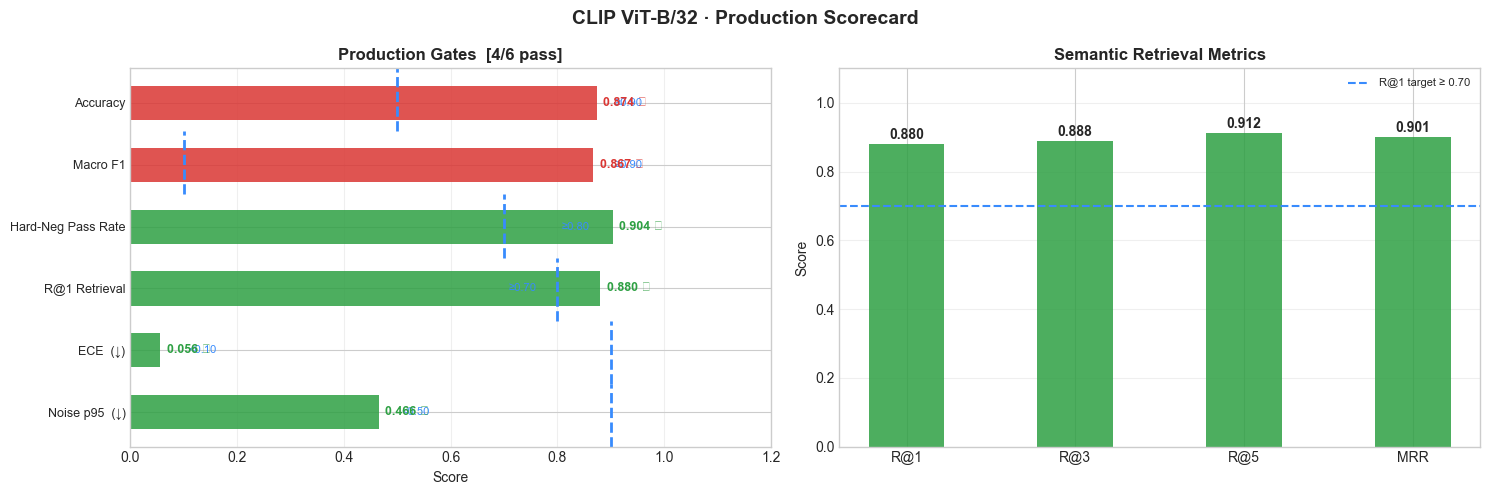

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("CLIP ViT-B/32 · Production Scorecard", fontsize=14, fontweight="bold")

# Scorecard bars
metrics_cfg = [
    ("Accuracy",          acc,           0.90, True),
    ("Macro F1",          macro_f1,      0.90, True),
    ("Hard-Neg Pass Rate", rate,          0.80, True),
    ("R@1 Retrieval",     ret["R@1"],    0.70, True),
    ("ECE  (↓)",          ece_final,     0.10, False),
    ("Noise p95  (↓)",    nc["p95"],     0.50, False),
]
names  = [m[0] for m in metrics_cfg]
values = [m[1] for m in metrics_cfg]
tgts   = [m[2] for m in metrics_cfg]
hb     = [m[3] for m in metrics_cfg]
passes = [(v >= t if h else v <= t) for v, t, h in zip(values, tgts, hb)]

bar_colors = ["#2ea043" if p else "#da3633" for p in passes]
ax1.barh(range(len(names)), values, color=bar_colors, alpha=0.85, height=0.55)
for i, (t, h) in enumerate(zip(tgts, hb)):
    ax1.axvline(t, ymin=i/len(names), ymax=(i+1)/len(names),
                color="#388bfd", lw=2, ls="--")
    ax1.text(t + 0.008, i, f"{'≥' if h else '<'}{t:.2f}",
             va="center", fontsize=8, color="#388bfd")
for i, (v, p) in enumerate(zip(values, passes)):
    ax1.text(v + 0.012, i, f"{v:.3f} {'✓' if p else '✗'}",
             va="center", fontsize=9, fontweight="bold",
             color="#2ea043" if p else "#da3633")

ax1.set_yticks(range(len(names)))
ax1.set_yticklabels(names, fontsize=9)
ax1.set_xlim(0, 1.2)
ax1.set_xlabel("Score")
ax1.set_title(f"Production Gates  [{sum(passes)}/{len(passes)} pass]", fontweight="bold")
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)

# R@K bars
rk = {"R@1": ret["R@1"], "R@3": ret["R@3"], "R@5": ret["R@5"], "MRR": ret["MRR"]}
rk_colors = ["#2ea043" if v >= 0.70 else "#f0883e" for v in rk.values()]
ax2.bar(rk.keys(), rk.values(), color=rk_colors, alpha=0.85, width=0.45)
ax2.axhline(0.70, color="#388bfd", ls="--", lw=1.5, label="R@1 target ≥ 0.70")
for i, (k, v) in enumerate(rk.items()):
    ax2.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Score")
ax2.set_title("Semantic Retrieval Metrics", fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_DIR / "01_scorecard.png", **SAVE_KW)
plt.show()


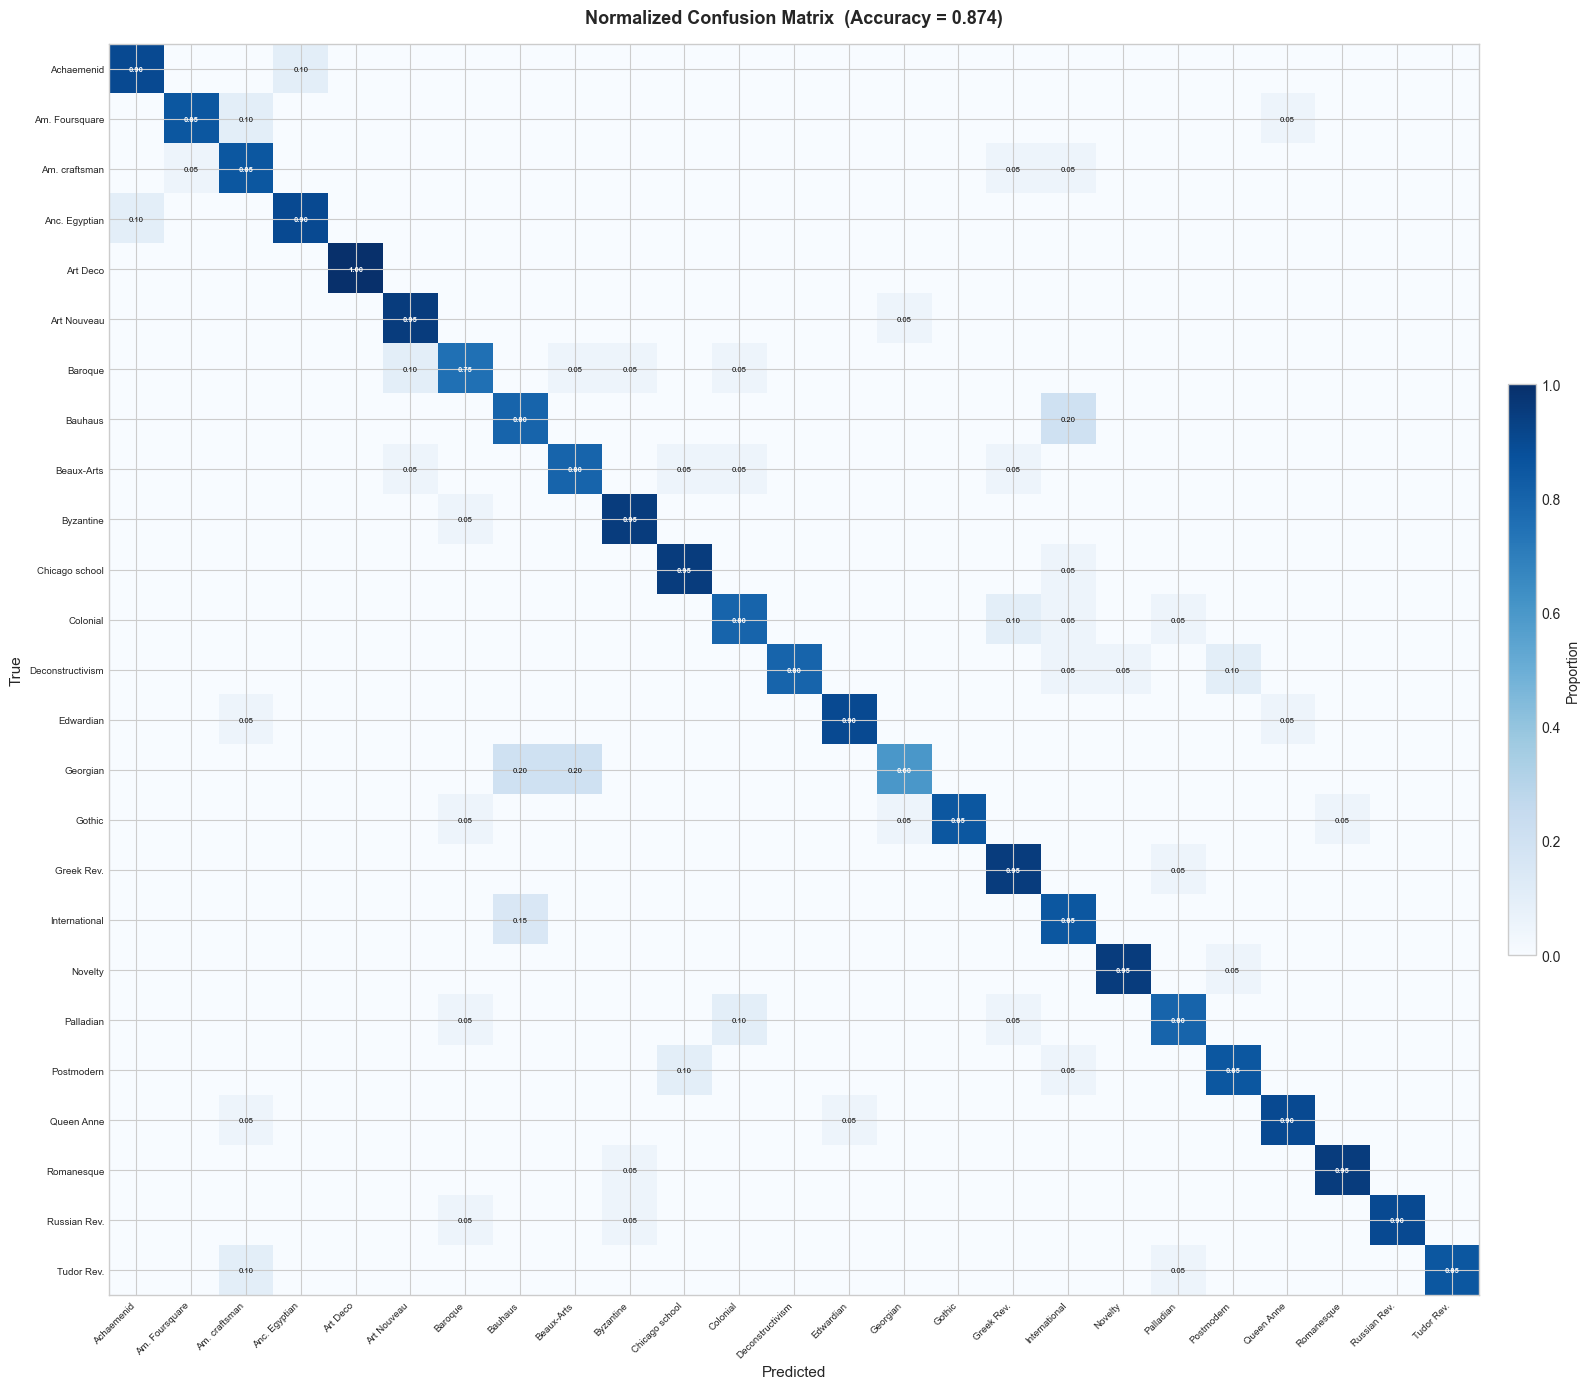

In [49]:
cm = confusion_matrix(val_tgts_np, val_preds, normalize="true")
n = len(CAL_CLASSES)

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="Proportion")

ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_labels, fontsize=7)

for i in range(n):
    for j in range(n):
        if cm[i, j] > 0.04:
            ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                    fontsize=5.5, fontweight="bold" if i == j else "normal",
                    color="white" if cm[i, j] > 0.55 else "black")

ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title(f"Normalized Confusion Matrix  (Accuracy = {acc:.3f})",
             fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(VIZ_DIR / "02_confusion_matrix.png", **SAVE_KW)
plt.show()


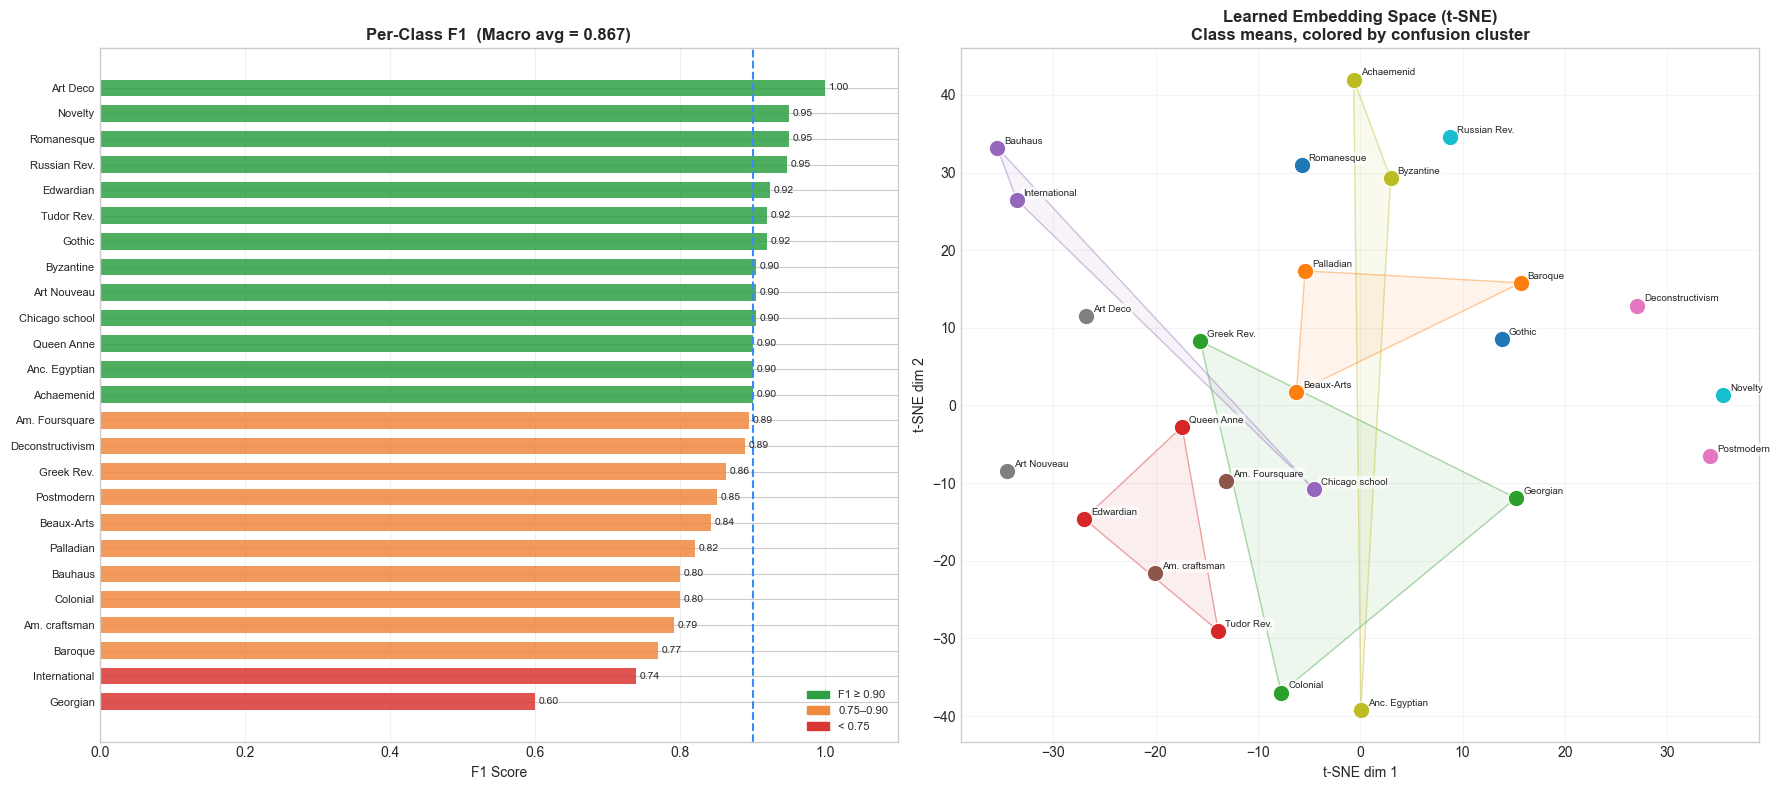

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Per-class F1 sorted
sort_idx = np.argsort(per_class_f1)
s_labels = [short_labels[i] for i in sort_idx]
s_f1     = [per_class_f1[i]  for i in sort_idx]
s_colors = ["#2ea043" if f >= 0.90 else "#f0883e" if f >= 0.75 else "#da3633" for f in s_f1]

ax1.barh(range(len(s_labels)), s_f1, color=s_colors, alpha=0.85, height=0.65)
ax1.axvline(0.90, color="#388bfd", ls="--", lw=1.5)
ax1.set_yticks(range(len(s_labels)))
ax1.set_yticklabels(s_labels, fontsize=8)
ax1.set_xlim(0, 1.1)
ax1.set_xlabel("F1 Score")
ax1.set_title(f"Per-Class F1  (Macro avg = {macro_f1:.3f})", fontweight="bold")
for i, v in enumerate(s_f1):
    ax1.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=7.5)
ax1.legend(handles=[
    mpatches.Patch(color="#2ea043", label="F1 ≥ 0.90"),
    mpatches.Patch(color="#f0883e", label="0.75–0.90"),
    mpatches.Patch(color="#da3633", label="< 0.75"),
], fontsize=8, loc="lower right")
ax1.grid(axis="x", alpha=0.3)

# t-SNE of class mean embeddings
cls_avail = [c for c in CAL_CLASSES if c in cls_mean]
emb_matrix = np.stack([cls_mean[c] for c in cls_avail])

tsne = TSNE(n_components=2, random_state=SEED,
            perplexity=min(8, len(cls_avail) - 1),
            learning_rate="auto", init="pca")
emb_2d = tsne.fit_transform(emb_matrix)

palette = plt.cm.tab10.colors
cls_ci = []
for c in cls_avail:
    found = next((ci for ci, cl in enumerate(CONFUSION_CLUSTERS) if c in cl), -1)
    cls_ci.append(found)

for i, (x, y) in enumerate(emb_2d):
    ci = cls_ci[i]
    color = palette[ci % 10] if ci >= 0 else "gray"
    ax2.scatter(x, y, c=[color], s=140, zorder=5, edgecolors="white", linewidths=0.8)
    ax2.annotate(shorten(cls_avail[i]), (x, y), xytext=(5, 3),
                 textcoords="offset points", fontsize=7,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))

# Convex hull per cluster
try:
    from scipy.spatial import ConvexHull
    for ci in range(len(CONFUSION_CLUSTERS)):
        idxs = [i for i, c in enumerate(cls_ci) if c == ci]
        if len(idxs) < 3:
            continue
        pts = emb_2d[idxs]
        hull = ConvexHull(pts)
        verts = np.vstack([pts[hull.vertices], pts[hull.vertices[0]]])
        ax2.fill(verts[:, 0], verts[:, 1], alpha=0.08, color=palette[ci % 10])
        ax2.plot(verts[:, 0], verts[:, 1], alpha=0.35, color=palette[ci % 10], lw=1)
except Exception:
    pass

ax2.set_title("Learned Embedding Space (t-SNE)\nClass means, colored by confusion cluster",
              fontweight="bold")
ax2.set_xlabel("t-SNE dim 1"); ax2.set_ylabel("t-SNE dim 2")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(VIZ_DIR / "03_f1_tsne.png", **SAVE_KW)
plt.show()


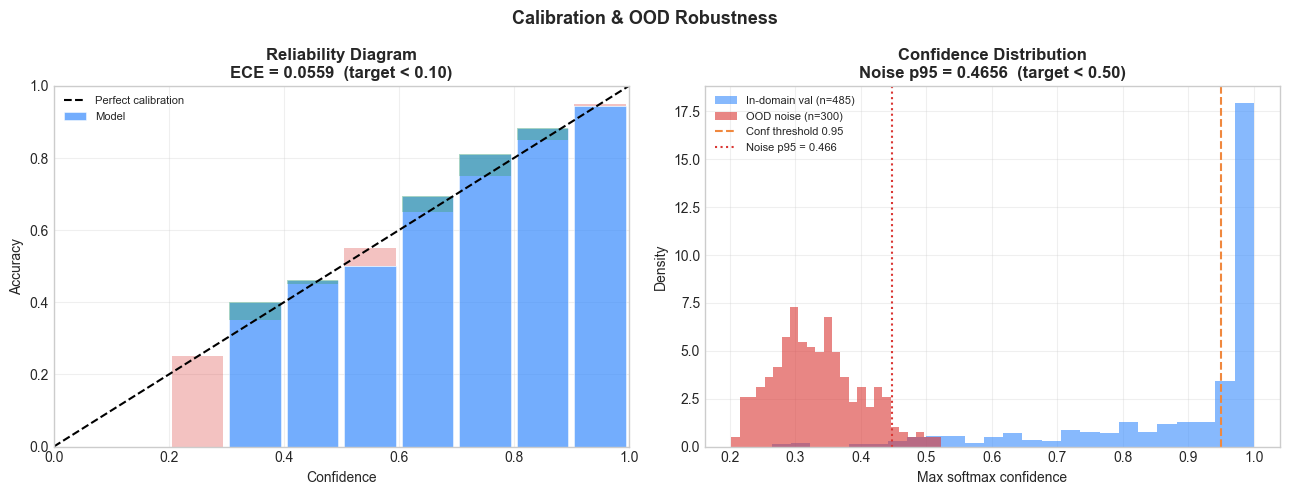


All figures saved to: checkpoints\artifacts\viz
Files: ['01_scorecard.png', '02_confusion_matrix.png', '03_f1_tsne.png', '04_calibration_ood.png']


In [53]:
from PIL import Image as PILImage

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Calibration & OOD Robustness", fontsize=13, fontweight="bold")

# Reliability diagram
probs_np = val_logits_cal.softmax(dim=-1).detach().numpy()
confs    = probs_np.max(axis=1)
correct  = (val_preds == val_tgts_np).astype(float)

n_bins = 10
edges  = np.linspace(0, 1, n_bins + 1)
centers = (edges[:-1] + edges[1:]) / 2
bin_acc, bin_conf = [], []
for i in range(n_bins):
    mask = (confs >= edges[i]) & (confs < edges[i + 1])
    bin_acc.append(correct[mask].mean() if mask.sum() > 0 else np.nan)
    bin_conf.append(confs[mask].mean() if mask.sum() > 0 else centers[i])

ax1.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration")
valid = ~np.isnan(bin_acc)
ax1.bar(np.array(centers)[valid], np.array(bin_acc)[valid],
        width=0.09, alpha=0.7, color="#388bfd", label="Model", ec="white", lw=0.5)
for i in range(n_bins):
    if valid[i]:
        lo, hi = min(bin_acc[i], centers[i]), max(bin_acc[i], centers[i])
        color = "#da3633" if bin_acc[i] < centers[i] else "#2ea043"
        ax1.bar(centers[i], hi - lo, bottom=lo, width=0.09, alpha=0.3, color=color)

ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.set_xlabel("Confidence"); ax1.set_ylabel("Accuracy")
ax1.set_title(f"Reliability Diagram\nECE = {ece_final:.4f}  (target < 0.10)", fontweight="bold")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# OOD noise confidence histogram
model.eval(); model.to(DEVICE)
with torch.no_grad():
    tok_txt = tokenizer([LABEL_PROMPTS[c][0] for c in CAL_CLASSES]).to(DEVICE)
    txt_f   = model.encode_text(tok_txt)
    txt_f   = txt_f / txt_f.norm(dim=-1, keepdim=True)

noise_confs = []
with torch.no_grad():
    for _ in range(300):
        arr = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
        x = val_preprocess(PILImage.fromarray(arr)).unsqueeze(0).to(DEVICE)
        f = model.encode_image(x)
        f = f / f.norm(dim=-1, keepdim=True)
        noise_confs.append(float(((100.0 / T_saved) * (f @ txt_f.T)).softmax(dim=-1).max()))

noise_arr = np.array(noise_confs)
ax2.hist(confs,       bins=25, alpha=0.6, color="#388bfd", density=True,
         label=f"In-domain val (n={len(confs)})")
ax2.hist(noise_arr,   bins=25, alpha=0.6, color="#da3633", density=True,
         label=f"OOD noise (n={len(noise_arr)})")
ax2.axvline(0.95, color="#f0883e", ls="--", lw=1.5, label="Conf threshold 0.95")
ax2.axvline(float(np.percentile(noise_arr, 95)), color="#da3633", ls=":",
            lw=1.5, label=f"Noise p95 = {nc['p95']:.3f}")
ax2.set_xlabel("Max softmax confidence")
ax2.set_ylabel("Density")
ax2.set_title(f"Confidence Distribution\nNoise p95 = {nc['p95']:.4f}  (target < 0.50)", fontweight="bold")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_DIR / "04_calibration_ood.png", **SAVE_KW)
plt.show()

print(f"\nAll figures saved to: {VIZ_DIR}")
print("Files:", [f.name for f in sorted(VIZ_DIR.glob("*.png"))])


## Notes

### Oversampling rationale
Smallest class (Deconstructivism, 122) oversampled to 280 with replacement.
Strong augmentation (rotation, perspective, color jitter, grayscale) ensures
each copy is genuinely different. This is equivalent to ~3x the raw data.
No new images needed.

### If hard-neg pass rate stays < 0.80
- Increase `BATCH_SIZE` to 32 (more negatives per step, stronger signal)
- Increase `S2_EPOCHS` to 15
- Add explicit negative pairs: for each image, pair with a wrong prompt
  from the same confusion cluster and push similarity down

### If ECE stays > 0.10
- Increase `LABEL_SMOOTHING` to 0.2
- Use separate calibration split (not val set)

### Production embedder integration (ONNX path)
Replace `open_clip.create_model_and_transforms` in `embedder.py`:
```python
import onnxruntime as ort
so = ort.SessionOptions()
so.intra_op_num_threads = 2
sess = ort.InferenceSession("clip_visual_int8.onnx", so,
                             providers=["CPUExecutionProvider"])
# embed_image:
embedding = sess.run(None, {"image": preprocessed_np})[0]  # (1, 512)
```
Text embeddings load from `clip_artifacts.pkl` — no text encoder at query time.